# Create 10 meter 30 meter buffer and unique building ID

1. Setup and Directory Management

    Define Input and Output Paths:
        Input Directory: Contains raw zoom level 9 structure polygon Feather files.
        Output Directory: Organized into subfolders for original data with unique IDs and buffered geometries (30m and 10m buffers).

    Create Necessary Directories:
        Ensure that all required output directories exist using os.makedirs.

    Coordinate Reference Systems (CRS):
        Original CRS: EPSG:4326 (WGS 84) for geographic coordinates.
        Equal Area CRS: EPSG:3395 (World Mercator) for accurate area-based operations like buffering.

2. Adding Unique Identifiers to Original Data

    Functionality:
        Read Each Feather File: Load geospatial data for each zoom level 9 tile.
        Assign Unique IDs: Generate a unique identifier for each geometry by combining the tile ID with a sequential number.
        Save Modified Data: Write the updated GeoDataFrame with unique IDs back to a Feather file in the designated original_output_dir.

    Parallel Processing:
        Utilize ProcessPoolExecutor with multiple workers (e.g., 60) to process multiple files simultaneously.
        Monitor progress using tqdm for visual feedback.

3. Buffering Geometries

    Functionality:
        Read Data: Load the Feather files with unique IDs.
        CRS Transformation: Convert geometries to the equal area CRS (EPSG:3395) to ensure accurate buffering.
        Create Buffers: Apply specified buffer distances (30 meters and 10 meters) to each geometry.
        Update Geometry: Replace the original geometry with the buffered geometry and revert to the original CRS (EPSG:4326).
        Save Buffered Data: Write the buffered GeoDataFrames to their respective output directories (buffer_30m_output_dir and buffer_10m_output_dir).

    Parallel Processing:
        Use ProcessPoolExecutor with a suitable number of workers (e.g., 30) to handle buffering tasks concurrently.
        Track progress with tqdm.

4. Combining Zoom Level 9 Tiles into Zoom Level 7 Tiles

    Understanding Zoom Levels and Quadkeys:
        Zoom Level 9: More detailed tiles.
        Zoom Level 7: Aggregated tiles encompassing multiple zoom level 9 tiles.
        Quadkeys: Unique identifiers representing specific tiles at given zoom levels.

    Workflow:
        List Zoom Level 9 Files: Identify all Feather files corresponding to zoom level 9 tiles.
        Map to Zoom Level 7: For each zoom level 9 quadkey, determine its parent zoom level 7 quadkey.
        Aggregate Data:
            For each zoom level 7 quadkey, combine all associated zoom level 9 GeoDataFrames into a single GeoDataFrame.
            Save the aggregated data as Feather files in the zoom_7 output directories.

    Parallel Processing:
        Employ ProcessPoolExecutor (e.g., with 10 workers) to process multiple zoom level 7 tiles simultaneously.
        Use tqdm to display progress.

5. Visualizing Tiles and Study Area

    Setup:
        Directories: Specify input directories for zoom level 9 (buffered at 10m) and output directories for zoom level 7 (buffered at 10m).
        Shapefile: Load the study area boundary from a shapefile.

    Plotting Process:
        Initialize Plot: Create a matplotlib figure and axis.
        Plot Zoom Level 9 Tiles: Draw bounding boxes for each zoom level 9 tile in blue.
        Plot Zoom Level 7 Tiles: Draw bounding boxes for each zoom level 7 tile in red.
        Overlay Study Area: Plot the study area boundary in green on top of the tiles.
        Finalize Plot: Add labels, a legend, and a title, then display the plot.

    Error Handling:
        Handle and report any issues related to tile parsing to ensure the plotting process remains robust.

6. Calculating Centroids of Polygons

    Functionality:
        Create Output Directory: Ensure the folder for centroid CSVs exists.
        Process Each Feather File:
            Read Data: Load the Feather file into a GeoDataFrame.
            CRS Handling: Ensure the data is in the correct CRS (EPSG:4326).
            Chunking: Split the data into manageable chunks (e.g., 100 records per chunk) for processing.
            Calculate Centroids: For each polygon, compute its representative point (centroid).
            Save Results: Combine all centroids and save them as a CSV file in the designated output folder.

    Parallel Processing:
        Use ProcessPoolExecutor with multiple workers (e.g., 20) to process data chunks concurrently.
        Monitor the processing progress with tqdm.

    Execution:
        Define a main function to orchestrate the centroid calculation process across all relevant Feather files.

In [ ]:
import os
import concurrent.futures
from tqdm import tqdm
import geopandas as gpd
import pandas as pd
import gc  # Garbage collection

# Define input and output directories
input_dir = "/home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/zoom_9_raw"
output_dir = "/home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/building_defensible_space_polygons"
os.makedirs(output_dir, exist_ok=True)

original_output_dir = os.path.join(output_dir, "zoom_9_original")
buffer_30m_output_dir = os.path.join(output_dir, "zoom_9_buffer_30m")
buffer_10m_output_dir = os.path.join(output_dir, "zoom_9_buffer_10m")

os.makedirs(original_output_dir, exist_ok=True)
os.makedirs(buffer_30m_output_dir, exist_ok=True)
os.makedirs(buffer_10m_output_dir, exist_ok=True)

# Define the CRS transformations
original_crs = "EPSG:4326"
equal_area_crs = "EPSG:3395"  # World Mercator projection for equal area calculation

def add_ids_and_save_original(file_path):
    try:
        original_output_path = os.path.join(original_output_dir, os.path.basename(file_path))
        
        # Check if the output file already exists
        if os.path.exists(original_output_path):
            return original_output_path
        
        gdf = gpd.read_feather(file_path)
        
        # Assign unique IDs
        tile_id = os.path.splitext(os.path.basename(file_path))[0]
        gdf["unique_id"] = [f"{tile_id}_{i}" for i in range(len(gdf))]
        
        # Save the original dataframe with unique IDs
        gdf.to_feather(original_output_path)
        return original_output_path
    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
        return None

def buffer_and_save(file_path, buffer_distance, output_dir):
    try:
        output_path = os.path.join(output_dir, os.path.basename(file_path))
        
        # Check if the output file already exists
        if os.path.exists(output_path):
            return None
        
        gdf = gpd.read_feather(file_path)
        
        # Transform to equal area CRS
        gdf = gdf.to_crs(equal_area_crs)
        
        # Create buffer
        gdf[f"geometry_{buffer_distance}m"] = gdf.geometry.buffer(buffer_distance)
        
        # Drop the original geometry
        gdf = gdf.drop(columns="geometry")
        
        # Set the buffered geometry as the new geometry
        gdf = gdf.set_geometry(f"geometry_{buffer_distance}m")
        
        # Transform back to original CRS
        gdf = gdf.to_crs(original_crs)
        
        # Save the final dataframe
        gdf.to_feather(output_path)
        return output_path
    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
        return None

try:
    # Get the list of input files
    input_files = [os.path.join(input_dir, f) for f in os.listdir(input_dir) if f.endswith('.feather')]

    print("Starting parallel processing with concurrent.futures...")

    # Step 1: Add unique IDs and save original files
    with concurrent.futures.ProcessPoolExecutor(max_workers=60) as executor:
        futures_original = {executor.submit(add_ids_and_save_original, file_path): file_path for file_path in input_files}
        with tqdm(total=len(futures_original), desc="Saving original files with unique IDs") as pbar:
            for future in concurrent.futures.as_completed(futures_original):
                future.result()
                pbar.update(1)

    # Intermediate files with IDs added
    intermediate_files = [os.path.join(original_output_dir, os.path.basename(file)) for file in input_files]

    # Step 2: Buffer and save buffered files
    with concurrent.futures.ProcessPoolExecutor(max_workers=30) as executor:
        futures_30m = {executor.submit(buffer_and_save, file_path, 30, buffer_30m_output_dir): file_path for file_path in intermediate_files}
        with tqdm(total=len(futures_30m), desc="Creating 30m buffers") as pbar:
            for future in concurrent.futures.as_completed(futures_30m):
                future.result()
                pbar.update(1)

        futures_10m = {executor.submit(buffer_and_save, file_path, 10, buffer_10m_output_dir): file_path for file_path in intermediate_files}
        with tqdm(total=len(futures_10m), desc="Creating 10m buffers") as pbar:
            for future in concurrent.futures.as_completed(futures_10m):
                future.result()
                pbar.update(1)

except KeyboardInterrupt:
    print("Keyboard interrupt received. Shutting down...")

finally:
    print("All files processed and saved.")




Starting parallel processing with concurrent.futures...


Creating 10m buffers: 100%|██████████| 1429/1429 [01:37<00:00, 14.62it/s]


All files processed and saved.


# Combine polygons into zoom 7 mercator for future processing efficiencey

In [2]:
import os
import geopandas as gpd
import pandas as pd
from tqdm import tqdm
from mercantile import parent, quadkey_to_tile, quadkey, TileArgParsingError
import concurrent.futures

def get_zoom7_tile(zoom9_quadkey):
    """
    Given a quadkey of zoom level 9, return the corresponding zoom level 7 quadkey.
    """
    try:
        tile = quadkey_to_tile(zoom9_quadkey)
        zoom7_tile = parent(tile.x, tile.y, tile.z, zoom=7)
        return quadkey(zoom7_tile)
    except TileArgParsingError as e:
        print(f"Error parsing tile for quadkey {zoom9_quadkey}: {e}")
        return None

def process_single_zoom7_tile(zoom7_quadkey, zoom7_to_zoom9, input_dir, output_dir):
    combined_gdf = gpd.GeoDataFrame()
    for zoom9_quadkey in zoom7_to_zoom9[zoom7_quadkey]:
        file_path = os.path.join(input_dir, f"{zoom9_quadkey}.feather")
        if os.path.exists(file_path):
            gdf = gpd.read_feather(file_path)
            combined_gdf = pd.concat([combined_gdf, gdf], ignore_index=True)
    if not combined_gdf.empty:
        output_path = os.path.join(output_dir, f"{zoom7_quadkey}.feather")
        combined_gdf.to_feather(output_path)
    return zoom7_quadkey

def process_zoom_tiles(input_dir, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    # Step 1: Get all zoom 9 quad keys from the folder
    zoom9_files = [f for f in os.listdir(input_dir) if f.endswith('.feather')]
    zoom9_quadkeys = [os.path.splitext(f)[0] for f in zoom9_files]

    # Step 2: Map each zoom 9 tile to its corresponding zoom 7 tile
    zoom7_to_zoom9 = {}
    for zoom9_quadkey in zoom9_quadkeys:
        zoom7_quadkey = get_zoom7_tile(zoom9_quadkey)
        if zoom7_quadkey:
            if zoom7_quadkey not in zoom7_to_zoom9:
                zoom7_to_zoom9[zoom7_quadkey] = []
            zoom7_to_zoom9[zoom7_quadkey].append(zoom9_quadkey)

    # Step 3: Get unique list of zoom 7 quad keys
    unique_zoom7_quadkeys = list(zoom7_to_zoom9.keys())

    # Step 4: For each zoom 7 quad key, read in all associated zoom 9 files, combine them, and save
    with concurrent.futures.ProcessPoolExecutor(max_workers=10) as executor:
        futures = {executor.submit(process_single_zoom7_tile, zoom7_quadkey, zoom7_to_zoom9, input_dir, output_dir): zoom7_quadkey for zoom7_quadkey in unique_zoom7_quadkeys}
        for future in tqdm(concurrent.futures.as_completed(futures), total=len(futures), desc=f"Combining tiles for {input_dir}"):
            future.result()

    print(f"All files processed and combined for {input_dir}.")

# Define input and output directories
directories = [
    "zoom_9_buffer_10m",
    "zoom_9_buffer_30m",
    "zoom_9_original"
]

base_input_dir = "/home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/building_defensible_space_polygons"
base_output_dir = "/home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/building_defensible_space_polygons"

for dir_name in directories:
    input_dir = os.path.join(base_input_dir, dir_name)
    output_dir = os.path.join(base_output_dir, dir_name.replace("zoom_9", "zoom_7"))
    process_zoom_tiles(input_dir, output_dir)

print("All folders processed and combined.")


Combining tiles for /home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/building_defensible_space_polygons/zoom_9_buffer_10m:   0%|          | 0/136 [00:00<?, ?it/s]

Combining tiles for /home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/building_defensible_space_polygons/zoom_9_buffer_10m: 100%|██████████| 136/136 [01:01<00:00,  2.22it/s]


All files processed and combined for /home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/building_defensible_space_polygons/zoom_9_buffer_10m.


Combining tiles for /home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/building_defensible_space_polygons/zoom_9_buffer_30m: 100%|██████████| 136/136 [01:10<00:00,  1.93it/s]


All files processed and combined for /home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/building_defensible_space_polygons/zoom_9_buffer_30m.


Combining tiles for /home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/building_defensible_space_polygons/zoom_9_original: 100%|██████████| 136/136 [00:20<00:00,  6.66it/s]


All files processed and combined for /home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/building_defensible_space_polygons/zoom_9_original.
All folders processed and combined.


### Create Lat Lon Centroids

In [5]:
import os
import pandas as pd
import pyarrow.feather as feather
from shapely.geometry import Polygon
from shapely.wkb import loads as wkb_loads
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm
import geopandas as gpd

def create_new_folder(folder_path):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
    print(f"Created new folder at: {folder_path}")

def calculate_representative_point(polygon):
    return polygon.representative_point()

def process_chunk(chunk):
    centroids = []
    
    for _, row in chunk.iterrows():
        geom = wkb_loads(row['geometry'])
        
        if isinstance(geom, Polygon):
            rep_point = calculate_representative_point(geom)
            centroids.append({
                'unique_id': row['unique_id'],
                'centroid_lat': rep_point.y,
                'centroid_lon': rep_point.x
            })
    
    return pd.DataFrame(centroids)

def process_feather_file(file_path, new_folder, chunk_size, num_cores):
    print(f"Processing file: {file_path}")
    
    # Read the file using geopandas to extract the CRS
    df = feather.read_feather(file_path)
    gdf = gpd.GeoDataFrame(df, geometry=gpd.GeoSeries.from_wkb(df['geometry']))
    
    # Set the CRS explicitly (if missing) to EPSG:4326
    if gdf.crs is None:
        gdf.crs = "EPSG:4326"
    
    print(f"CRS for {file_path}: {gdf.crs}")
    
    # Split data into chunks
    chunks = [df[i:i + chunk_size] for i in range(0, df.shape[0], chunk_size)]
    
    # Process chunks using multiprocessing
    results = []
    with ProcessPoolExecutor(max_workers=num_cores) as executor:
        futures = []
        for chunk in chunks:
            futures.append(executor.submit(process_chunk, chunk))
        
        for future in tqdm(futures, desc="Processing Chunks"):
            results.append(future.result())
    
    # Combine results and save as CSV
    combined_df = pd.concat(results)
    new_file_path = os.path.join(new_folder, os.path.basename(file_path).replace('.feather', '.csv'))
    combined_df.to_csv(new_file_path, index=False)
    print(f"Saved new CSV file at: {new_file_path}")

def main():
    original_folder = '/home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/building_defensible_space_polygons/zoom_7_original'
    new_folder = '/home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/building_defensible_space_polygons/zoom_7_centroids'
    chunk_size = 100  # Set your chunk size here
    num_cores = 20  # Set the number of cores you want to use here
    
    create_new_folder(new_folder)
    
    for file_name in os.listdir(original_folder):
        if file_name.endswith('.feather'):
            file_path = os.path.join(original_folder, file_name)
            process_feather_file(file_path, new_folder, chunk_size, num_cores)

if __name__ == "__main__":
    main()



Created new folder at: /home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/building_defensible_space_polygons/zoom_7_centroids
Processing file: /home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/building_defensible_space_polygons/zoom_7_original/0231031.feather
CRS for /home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/building_defensible_space_polygons/zoom_7_original/0231031.feather: EPSG:4326


Processing Chunks: 100%|██████████| 426/426 [00:00<00:00, 2489.76it/s]


Saved new CSV file at: /home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/building_defensible_space_polygons/zoom_7_centroids/0231031.csv
Processing file: /home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/building_defensible_space_polygons/zoom_7_original/0212120.feather
CRS for /home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/building_defensible_space_polygons/zoom_7_original/0212120.feather: EPSG:4326


Processing Chunks: 100%|██████████| 247/247 [00:00<00:00, 2496.87it/s]

Saved new CSV file at: /home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/building_defensible_space_polygons/zoom_7_centroids/0212120.csv
Processing file: /home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/building_defensible_space_polygons/zoom_7_original/0212003.feather
CRS for /home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/building_defensible_space_polygons/zoom_7_original/0212003.feather: EPSG:4326


...

Saved new CSV file at: /home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/building_defensible_space_polygons/zoom_7_centroids/0212132.csv
Processing file: /home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/building_defensible_space_polygons/zoom_7_original/0213231.feather
CRS for /home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/building_defensible_space_polygons/zoom_7_original/0213231.feather: EPSG:4326


Processing Chunks: 100%|██████████| 2/2 [00:00<00:00, 312.66it/s]


Saved new CSV file at: /home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/building_defensible_space_polygons/zoom_7_centroids/0213231.csv
Processing file: /home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/building_defensible_space_polygons/zoom_7_original/0213232.feather
CRS for /home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/building_defensible_space_polygons/zoom_7_original/0213232.feather: EPSG:4326


Processing Chunks: 100%|██████████| 1509/1509 [00:00<00:00, 2455.34it/s]


Saved new CSV file at: /home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/building_defensible_space_polygons/zoom_7_centroids/0213232.csv


# Plot the zoom 7 and Zoom 9 tile

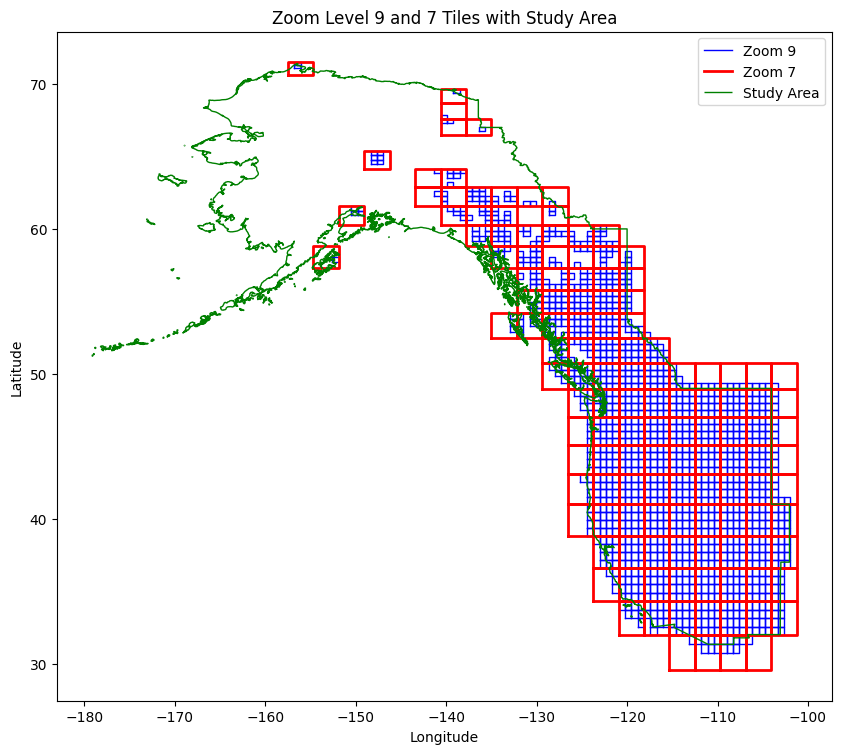

In [6]:
import os
import matplotlib.pyplot as plt
from mercantile import tile, bounds, quadkey_to_tile, TileArgParsingError
import geopandas as gpd

# Define input and output directories for 10m buffer
base_input_dir = "/home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/building_defensible_space_polygons/"
base_output_dir = "/home/shares/wwri-wildfire/data/built-environment-domain-data/defensible-space/structure-polygons/building_defensible_space_polygons/"
shapefile_path = "/home/shares/wwri-wildfire/data/multi-domain-data/boundary-layers/processed/admin-boundary-layers/wwri_study_area_admin_0.shp"

input_dir_10m = os.path.join(base_input_dir, "zoom_9_buffer_10m")
output_dir_10m = os.path.join(base_output_dir, "zoom_7_buffer_10m")

# Get the CRS from one of the tiles
example_file = os.listdir(input_dir_10m)[0]
quadkey_str = os.path.splitext(example_file)[0]
t = quadkey_to_tile(quadkey_str)
bbox = bounds(t)

# Extracting the CRS as EPSG:3857 for Web Mercator projection
tile_crs = "EPSG:4326"

# Read the shapefile
study_area_gdf = gpd.read_file(shapefile_path)

# Plot setup
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot zoom level 9 tiles
for file_name in os.listdir(input_dir_10m):
    if file_name.endswith('.feather'):
        quadkey_str = os.path.splitext(file_name)[0]
        try:
            t = quadkey_to_tile(quadkey_str)
            bbox = bounds(t)
            ax.plot([bbox.west, bbox.east, bbox.east, bbox.west, bbox.west],
                    [bbox.south, bbox.south, bbox.north, bbox.north, bbox.south],
                    color='blue', linewidth=1, label='Zoom 9' if 'Zoom 9' not in [line.get_label() for line in ax.get_lines()] else "")

        except TileArgParsingError as e:
            print(f"Error parsing tile for quadkey {quadkey_str}: {e}")

# Plot zoom level 7 tiles
for file_name in os.listdir(output_dir_10m):
    if file_name.endswith('.feather'):
        quadkey_str = os.path.splitext(file_name)[0]
        try:
            t = quadkey_to_tile(quadkey_str)
            bbox = bounds(t)
            ax.plot([bbox.west, bbox.east, bbox.east, bbox.west, bbox.west],
                    [bbox.south, bbox.south, bbox.north, bbox.north, bbox.south],
                    color='red', linewidth=2, label='Zoom 7' if 'Zoom 7' not in [line.get_label() for line in ax.get_lines()] else "")

        except TileArgParsingError as e:
            print(f"Error parsing tile for quadkey {quadkey_str}: {e}")

# Reproject and plot the study area polygon on top of the tiles
study_area_gdf = study_area_gdf.to_crs(tile_crs)
study_area_gdf.boundary.plot(ax=ax, color='green', linewidth=1, label='Study Area')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()
ax.set_title('Zoom Level 9 and 7 Tiles with Study Area')

plt.show()

